In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.io import loadmat
from scipy.cluster import hierarchy

in_dir = Path('/media/ubuntu/sda/TrippleN/human_fMRI')
cluster_mat = Path('/media/ubuntu/sda/TrippleN/ClusInfo.mat')
out_dir = Path('/media/ubuntu/sda/TrippleN/customize/human_fMRI/selectivity')
fig_dir = out_dir / 'figures'
selectivity_threshold = 0.3
n_plot = 3000
seed = 42

out_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

m = loadmat(str(cluster_mat))
if 'Cluster_idx' not in m:
    raise KeyError(f'Cluster_idx not found in {cluster_mat}')
cluster_flat = np.asarray(m['Cluster_idx']).flatten()

files = sorted(in_dir.glob('resp_*_func1py8mm.npy'))
if len(files) == 0:
    raise FileNotFoundError(f'No resp_*_func1py8mm.npy found in {in_dir}')

rows = []
si_mats = []
region_offsets = []
region_si = {}
cursor = 0

for p in files:
    name = p.stem
    if name.startswith('resp_'):
        name = name[len('resp_'):]
    if name.endswith('_func1py8mm'):
        region = name[:-len('_func1py8mm')]
    else:
        region = name

    arr = np.load(str(p), allow_pickle=False)
    if arr.ndim != 2:
        raise ValueError(f'{p} expected 2D array, got shape {arr.shape}')

    n_stim = arr.shape[1]
    if cluster_flat.shape[0] != n_stim:
        raise ValueError(f'cluster length {cluster_flat.shape[0]} != n_stim {n_stim} for {p.name}')

    cluster_ids = np.unique(cluster_flat)
    n_units = arr.shape[0]
    n_clusters = len(cluster_ids)

    arr_mean = arr.mean(axis=1, keepdims=True)
    arr_std = arr.std(axis=1, keepdims=True)
    arr_z = (arr.astype(np.float64) - arr_mean) / (arr_std + 1e-10)

    z_var = arr_z.var(axis=1)
    print(
        f"{region}: zscore var mean={z_var.mean():.4f}, median={np.median(z_var):.4f}, "
        f"pct_in_[0.95,1.05]={(((z_var >= 0.95) & (z_var <= 1.05)).mean() * 100):.2f}%"
    )

    rmin = arr_z.min(axis=1, keepdims=True)
    rmax = arr_z.max(axis=1, keepdims=True)
    R = 2.0 * (arr_z - rmin) / (rmax - rmin + 1e-10) - 1.0

    SI_clusters = np.zeros((n_units, n_clusters), dtype=np.float64)
    for j in range(n_clusters):
        mask_c = (cluster_flat == cluster_ids[j])
        mask_n = ~mask_c
        m_cat = R[:, mask_c].mean(axis=1)
        m_non = R[:, mask_n].mean(axis=1)
        v_cat = R[:, mask_c].var(axis=1)
        v_non = R[:, mask_n].var(axis=1)
        SI_clusters[:, j] = (m_cat - m_non) / np.sqrt(0.5 * (v_cat + v_non) + 1e-10)

    df = pd.DataFrame(SI_clusters, columns=[f'C{j}_SI' for j in range(n_clusters)])
    for j in range(n_clusters):
        df[f'C{j}_selectivity'] = (df[f'C{j}_SI'] > selectivity_threshold).astype(int)
    df.insert(0, 'unit_index', np.arange(n_units, dtype=int))
    df.insert(0, 'region', region)
    df.insert(0, 'global_unit_id', np.arange(cursor, cursor + n_units, dtype=int))

    rows.append(df)
    si_mats.append(SI_clusters)
    region_si[region] = SI_clusters
    region_offsets.append((region, cursor, cursor + n_units))
    cursor += n_units

unit_info = pd.concat(rows, ignore_index=True)
SI_all = np.concatenate(si_mats, axis=0)

n_clusters = SI_all.shape[1]
si_cols = [f'C{j}_SI' for j in range(n_clusters)]
sel_cols = [f'C{j}_selectivity' for j in range(n_clusters)]

unit_csv = out_dir / 'human_fMRI_unit_selectivity.csv'
unit_pkl = out_dir / 'human_fMRI_unit_selectivity.pkl'
si_csv = out_dir / 'human_fMRI_SI_matrix.csv'
sel_csv = out_dir / 'human_fMRI_selectivity_matrix_binary.csv'
meta_csv = out_dir / 'human_fMRI_unit_index_map.csv'

unit_info.to_csv(unit_csv, index=False)
unit_info.to_pickle(unit_pkl)
pd.DataFrame(SI_all, columns=si_cols).to_csv(si_csv, index=False)
pd.DataFrame(unit_info[sel_cols].to_numpy(dtype=int), columns=sel_cols).to_csv(sel_csv, index=False)
pd.DataFrame(region_offsets, columns=['region', 'global_unit_id_start', 'global_unit_id_end']).to_csv(meta_csv, index=False)

sns.set_style('white')
plt.rcParams['axes.grid'] = False

region_fig_dir = fig_dir / 'per_region'
region_fig_dir.mkdir(parents=True, exist_ok=True)

cmap_cluster = plt.cm.tab20
col_color = np.array([cmap_cluster(i % 20) for i in range(n_clusters)])
col_color_hex = ['#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255)) for r, g, b, _ in col_color]

for region_name in sorted(region_si.keys()):
    si_region = region_si[region_name]
    df_region = unit_info[unit_info['region'] == region_name].copy().reset_index(drop=True)

    n_cluster_sel = sum(df_region[f'C{j}_selectivity'] for j in range(n_clusters))
    tuning_type = np.array(['mixed_tuning'] * len(df_region), dtype=object)
    tuning_type[n_cluster_sel == 0] = 'no_tuning'
    tuning_type[n_cluster_sel == 1] = 'single_tuning'
    selective_cluster = np.full(len(df_region), -1, dtype=int)
    for j in range(n_clusters):
        selective_cluster[(df_region[f'C{j}_selectivity'].values == 1) & (n_cluster_sel.values == 1)] = j

    col_linkage = hierarchy.linkage(si_region.T, method='average')
    col_order = hierarchy.leaves_list(col_linkage)
    col_order_inv = np.zeros(n_clusters, dtype=int)
    col_order_inv[col_order] = np.arange(n_clusters)

    single_idx = np.where(tuning_type == 'single_tuning')[0]
    single_sort = single_idx[np.argsort(col_order_inv[selective_cluster[single_idx]])]
    mixed_idx = np.where(tuning_type == 'mixed_tuning')[0]
    no_idx = np.where(tuning_type == 'no_tuning')[0]
    sort_idx = np.concatenate([single_sort, mixed_idx, no_idx])

    R_plot = si_region[sort_idx]
    tuning_type_ordered = tuning_type[sort_idx]
    sel_cluster_ordered = selective_cluster[sort_idx]

    row_color_by_cluster = np.array(['#e0e0e0'] * len(sort_idx), dtype=object)
    row_color_by_cluster[tuning_type_ordered == 'mixed_tuning'] = '#EC6F7E'
    for j in range(n_clusters):
        row_color_by_cluster[(tuning_type_ordered == 'single_tuning') & (sel_cluster_ordered == j)] = col_color_hex[j]

    row_color_by_type = np.array(['#d9d9d9'] * len(sort_idx), dtype=object)
    row_color_by_type[tuning_type_ordered == 'single_tuning'] = '#8AB07C'
    row_color_by_type[tuning_type_ordered == 'mixed_tuning'] = '#EC6F7E'

    if n_plot is not None and R_plot.shape[0] > n_plot:
        sub_idx = np.arange(min(n_plot, R_plot.shape[0]))
        R_plot_use = R_plot[sub_idx]
        row_colors = [np.asarray(row_color_by_cluster[sub_idx]), np.asarray(row_color_by_type[sub_idx])]
    else:
        R_plot_use = R_plot
        row_colors = [np.asarray(row_color_by_cluster), np.asarray(row_color_by_type)]

    col_colors = [np.asarray(col_color_hex)]
    g = sns.clustermap(
        R_plot_use,
        row_cluster=False,
        col_cluster=True,
        col_linkage=col_linkage,
        method='average',
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        figsize=(14, 10),
        dendrogram_ratio=(0.15, 0.1),
        yticklabels=False,
        xticklabels=[f'C{j}' for j in range(n_clusters)],
        row_colors=row_colors,
        col_colors=col_colors,
    )

    g.ax_heatmap.set_xlabel('Cluster')
    g.ax_heatmap.set_ylabel('Unit')
    plt.suptitle(f'{region_name}: single/mixed/no tuning', y=1.02)

    out_pdf_region = region_fig_dir / f'human_fMRI_SI_heatmap_{region_name}.pdf'
    g.fig.savefig(out_pdf_region, bbox_inches='tight')
    plt.close(g.fig)
    print('Saved:', out_pdf_region)

print('Saved:', unit_csv)
print('Saved:', unit_pkl)
print('Saved:', si_csv)
print('Saved:', sel_csv)
print('Saved:', meta_csv)


early: zscore var mean=1.0000, median=1.0000, pct_in_[0.95,1.05]=100.00%
lateral: zscore var mean=1.0000, median=1.0000, pct_in_[0.95,1.05]=100.00%
midlateral: zscore var mean=1.0000, median=1.0000, pct_in_[0.95,1.05]=100.00%
midparietal: zscore var mean=1.0000, median=1.0000, pct_in_[0.95,1.05]=100.00%
midventral: zscore var mean=1.0000, median=1.0000, pct_in_[0.95,1.05]=100.00%
parietal: zscore var mean=1.0000, median=1.0000, pct_in_[0.95,1.05]=100.00%
ventral: zscore var mean=1.0000, median=1.0000, pct_in_[0.95,1.05]=100.00%
Saved: /media/ubuntu/sda/TrippleN/customize/human_fMRI/selectivity/figures/per_region/human_fMRI_SI_heatmap_early.pdf
Saved: /media/ubuntu/sda/TrippleN/customize/human_fMRI/selectivity/figures/per_region/human_fMRI_SI_heatmap_lateral.pdf
Saved: /media/ubuntu/sda/TrippleN/customize/human_fMRI/selectivity/figures/per_region/human_fMRI_SI_heatmap_midlateral.pdf
Saved: /media/ubuntu/sda/TrippleN/customize/human_fMRI/selectivity/figures/per_region/human_fMRI_SI_heatm

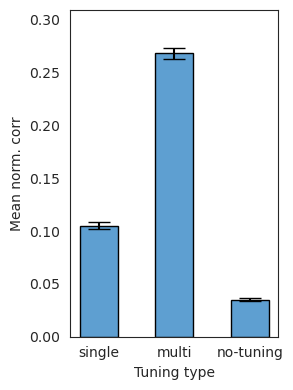

Saved: /media/ubuntu/sda/TrippleN/customize/human_fMRI/selectivity/figures/encoding_by_tuning_type_all_models.pdf
Saved: /media/ubuntu/sda/TrippleN/customize/human_fMRI/selectivity/figures/encoding_mean_norm_corr_by_tuning_x_model.csv


In [3]:
ENC_DIR = Path('/media/ubuntu/sda/TrippleN/customize/human_fMRI/encoding')
MATRIX_PKL = ENC_DIR / 'fmri_encoding_normalized_correlation_matrix.pkl'
VOXEL_CSV = ENC_DIR / 'fmri_encoding_voxel_info.csv'
UNIT_PKL = out_dir / 'human_fMRI_unit_selectivity.pkl'

if not MATRIX_PKL.is_file():
    raise FileNotFoundError(f'Missing encoding matrix (run 06_human_fMRI_analysis encoding cell first): {MATRIX_PKL}')
if not VOXEL_CSV.is_file():
    raise FileNotFoundError(f'Missing voxel info: {VOXEL_CSV}')
if not UNIT_PKL.is_file():
    raise FileNotFoundError(f'Run previous cell first to create {UNIT_PKL}')

norm_matrix = pd.read_pickle(MATRIX_PKL)
voxel_tab = pd.read_csv(VOXEL_CSV)
unit_tab = pd.read_pickle(UNIT_PKL)

sel_cols = [c for c in unit_tab.columns if c.startswith('C') and c.endswith('_selectivity')]
if len(sel_cols) == 0:
    raise KeyError('no C*_selectivity columns in unit selectivity table')
n_cluster_sel = unit_tab[sel_cols].sum(axis=1).to_numpy()
tt = np.array(['mixed_tuning'] * len(unit_tab), dtype=object)
tt[n_cluster_sel == 0] = 'no_tuning'
tt[n_cluster_sel == 1] = 'single_tuning'
unit_tab = unit_tab.copy()
unit_tab['cluster_tuning_type'] = tt

merge_keys = voxel_tab.merge(
    unit_tab[['region', 'unit_index', 'cluster_tuning_type']],
    left_on=['region', 'voxel_index'],
    right_on=['region', 'unit_index'],
    how='inner',
)
if len(merge_keys) != len(voxel_tab):
    print('warning: merged rows', len(merge_keys), 'vs voxels', len(voxel_tab))

model_cols = list(norm_matrix.columns)
n_models = len(model_cols)
mean_corr_matrix = np.full((3, n_models), np.nan, dtype=float)
tuning_order = ['single_tuning', 'mixed_tuning', 'no_tuning']
for j, m in enumerate(model_cols):
    for i, tname in enumerate(tuning_order):
        vid = merge_keys.loc[merge_keys['cluster_tuning_type'] == tname, 'voxel_id'].values
        if len(vid) == 0:
            continue
        col = norm_matrix.loc[norm_matrix.index.isin(vid), m]
        mean_corr_matrix[i, j] = float(np.nanmean(col.to_numpy()))

tuning_labels = ['single', 'multi', 'no-tuning']
y = np.nanmean(mean_corr_matrix, axis=1)
n_valid = np.isfinite(mean_corr_matrix).sum(axis=1)
yerr = np.nanstd(mean_corr_matrix, axis=1) / np.sqrt(np.maximum(n_valid, 1))
x_pos = np.arange(3)

fig, ax = plt.subplots(figsize=(3, 4))
ax.bar(x_pos, y, yerr=yerr, capsize=8, width=0.5, color='#5E9FD1', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(tuning_labels)
ax.set_ylabel('Mean norm. corr')
ax.set_xlabel('Tuning type')
lo = float(np.nanmin(y - yerr))
hi = float(np.nanmax(y + yerr))
pad = max(hi - lo, 1e-6) * 0.15
ax.set_ylim(max(0.0, lo - pad), hi + pad)
fig.tight_layout()

out_enc_fig = fig_dir / 'encoding_by_tuning_type_all_models.pdf'
fig.savefig(out_enc_fig, bbox_inches='tight')
plt.show()

df_mat = pd.DataFrame(mean_corr_matrix, index=tuning_labels, columns=model_cols)
df_mat.to_csv(fig_dir / 'encoding_mean_norm_corr_by_tuning_x_model.csv')
print('Saved:', out_enc_fig)
print('Saved:', fig_dir / 'encoding_mean_norm_corr_by_tuning_x_model.csv')
